# ECMWF Open Data: Download Methods

**Companion to [01](01_opendata_catalog.ipynb)** catalog tour and access overview.

This notebook covers programmatic download patterns for different use cases:
1. Direct full-file download (curl)
2. Python `requests` (resumable)
3. Single-parameter HTTP Range requests
4. `ecmwf-opendata` Python client
5. earthkit direct fetch (no file needed)

> **For cloud endpoint access** (AWS, Azure, GCS), see **04**.

> **Status note (July 2026):** Written against the ECMWF Free and Open Data catalogue as of mid-2026 (IFS cycle 50r1, 0.25 degree grid). An update to the Free and Open Data offering, including a move to 0.1 degree resolution, is expected later in 2026: file naming and catalogue examples here may need revisiting after that release.


## Appendix · CLI & Python downloads

To wrap our basic introduction to ECMWF open-data, we will also explore short examples of data access for slighlty more advanced programmatic access. You can reuse the printed examples and run them in your terminal or use these as foundation to **script** or **automate** downloads outside the notebook.

**Naming:** we save using the **remote filename** (e.g., `20250905120000-0h-oper-fc.grib2`), matching what you see on the ECMWF index page.

> If the rolling archive has updated (you started with this notebook a couple hours before), please refresh by re-running the selector cells on top (code cell 2 and 3) first, and then re-run the URL cell below.


In [2]:
# --- Appendix bridge for 02: find any cached GRIB + reconstruct state ---
from pathlib import Path
import re

# 0) Find a GRIB file - check globals first, then scan data cache
p = None
for name in ("TARGET_GRIB", "target"):
    if name in globals() and globals()[name]:
        candidate = Path(globals()[name])
        if candidate.exists():
            p = candidate
            break

if not p:
    try:
        from _utils import get_data_dir
        DATA_DIR = get_data_dir()
    except Exception:
        DATA_DIR = Path("data")
    # Find the NEWEST oper-fc GRIB in cache (rolling archive - filename changes daily)
    gribs = sorted(DATA_DIR.glob("*-0h-oper-fc.grib2"))
    if not gribs:
        gribs = sorted(DATA_DIR.glob("*.grib2"))
    if gribs:
        p = gribs[-1]
        print(f"Using cached file: {p.name}")

if not p or not p.exists():
    raise FileNotFoundError(
        f"No GRIB file found. Run 01 first to download one, or place any .grib2 in {DATA_DIR}"
    )

# 1) Shared data dir
try:
    from _utils import get_data_dir
    DATA_DIR = get_data_dir()
except Exception:
    DATA_DIR = Path("data")
    DATA_DIR.mkdir(exist_ok=True)

# 2) Parse filename: YYYYMMDDHHMMSS-<step>h-<suffix>.grib2
m = re.match(r'^(?P<ts>\d{14})-(?P<step>\d+)h-(?P<suffix>[^.]+)\.grib2$', p.name)

if m:
    ts = m.group("ts")
    date_str = ts[:8]
    run_str  = ts[8:10]
    step_h   = int(m.group("step"))
    product_suffix = m.group("suffix")
else:
    # Fallback for non-standard filenames
    date_str = globals().get("fc_date", "20260514")
    run_str  = globals().get("fc_time", "00")
    step_h   = 0
    product_suffix = "oper-fc"
    print(f"Could not parse filename {p.name!r} - using fallback state")

# 3) Reconstruct directory URL
stream = product_suffix.split("-")[0]
dir_url = f"https://data.ecmwf.int/forecasts/{date_str}/{run_str}z/ifs/0p25/{stream}/"

# 4) Variables appendix cells expect
FILENAME = p.name
FILE_URL = dir_url + FILENAME
IDX      = FILE_URL + ".index"

# 5) Picker shim
class _PickerShim:
    def __init__(self, local_path):
        self.last_path = Path(local_path)
        self.state = {
            "date": date_str, "run": run_str,
            "model": "ifs-single", "step": step_h,
            "dir_url": dir_url, "suffix": product_suffix,
        }
    def get_selected_local_path(self):
        return self.last_path

picker = _PickerShim(p)

print("Appendix bridge ready:")
print("  local file :", p)
print("  dir_url    :", dir_url)
print("  FILENAME   :", FILENAME)
print("  IDX        :", IDX)

# 6) Freshness guard: data.ecmwf.int keeps only a few days (rolling window).
# If the reconstructed state is older than 3 days, remote cells below would 404,
# so re-derive fresh state for yesterday's 00z run instead (downloads will fetch it).
from datetime import datetime, timedelta, timezone
_file_date = datetime.strptime(date_str, "%Y%m%d").replace(tzinfo=timezone.utc)
if datetime.now(timezone.utc) - _file_date > timedelta(days=3):
    y = datetime.now(timezone.utc) - timedelta(days=1)
    date_str, run_str, step_h, product_suffix = y.strftime("%Y%m%d"), "00", 0, "oper-fc"
    dir_url  = f"https://data.ecmwf.int/forecasts/{date_str}/{run_str}z/ifs/0p25/oper/"
    FILENAME = f"{date_str}{run_str}0000-{step_h}h-{product_suffix}.grib2"
    FILE_URL = dir_url + FILENAME
    IDX      = FILE_URL + ".index"
    picker = _PickerShim(DATA_DIR / FILENAME)
    picker.state.update({"date": date_str, "run": run_str, "dir_url": dir_url})
    p = DATA_DIR / FILENAME   # may not exist yet; download cells below fetch it
    print(f"Cached file older than the rolling archive window.")
    print(f"Re-derived fresh state: {FILENAME}")


Using cached file: 20260707120000-0h-oper-fc.grib2
Appendix bridge ready:
  local file : /Users/valtze/ecmwf-open-data-guide/data/20260707120000-0h-oper-fc.grib2
  dir_url    : https://data.ecmwf.int/forecasts/20260707/12z/ifs/0p25/oper/
  FILENAME   : 20260707120000-0h-oper-fc.grib2
  IDX        : https://data.ecmwf.int/forecasts/20260707/12z/ifs/0p25/oper/20260707120000-0h-oper-fc.grib2.index


In [3]:
from pathlib import Path
from _utils import get_data_dir

DATA_DIR = get_data_dir()

# Pull current state from the bridge cell
state = picker.state

# Build filename and URLs directly (no build_filename dependency)
FILENAME = p.name  # already resolved by bridge cell
URL      = f"{state['dir_url']}{FILENAME}"
IDX      = URL.replace(".grib2", ".index")

print("DATA_DIR:", DATA_DIR)
print("File name:", FILENAME)
print("File URL:", URL)
print("Index URL:", IDX)

DATA_DIR: /Users/valtze/ecmwf-open-data-guide/data
File name: 20260707120000-0h-oper-fc.grib2
File URL: https://data.ecmwf.int/forecasts/20260707/12z/ifs/0p25/oper/20260707120000-0h-oper-fc.grib2
Index URL: https://data.ecmwf.int/forecasts/20260707/12z/ifs/0p25/oper/20260707120000-0h-oper-fc.index


### 1) Direct full-file download

**When to use:** you need the whole GRIB (multiple parameters/levels).  
- **Notebook**: run this cell directly (save to `/data`).  
- **Terminal**: copy the printed commands.

In [4]:
# Jupyter (curl, resumable) → /data
!curl -L -C - -o "{DATA_DIR}/{FILENAME}" "{URL}"

# Terminal copy/paste
print(f'curl -L -C - -o "data/{FILENAME}" "{URL}"')
print(f'wget -c -O "data/{FILENAME}" "{URL}"')

** Resuming transfer from byte position 89039953
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 44.2M  100 44.2M    0     0  3108k      0  0:00:14  0:00:14 --:--:-- 3559k3k      0  0:00:33  0:00:01  0:00:32 1373k
curl -L -C - -o "data/20260707120000-0h-oper-fc.grib2" "https://data.ecmwf.int/forecasts/20260707/12z/ifs/0p25/oper/20260707120000-0h-oper-fc.grib2"
wget -c -O "data/20260707120000-0h-oper-fc.grib2" "https://data.ecmwf.int/forecasts/20260707/12z/ifs/0p25/oper/20260707120000-0h-oper-fc.grib2"


### 2) Python `requests` (resumable)

**When to use:** example to build programmatic workflows or CI. This will also resume download if file gets only partially downloaded.

In [5]:
import requests
dst = Path(DATA_DIR) / FILENAME
tmp = dst.with_suffix(dst.suffix + ".part")
pos = tmp.stat().st_size if tmp.exists() else 0
headers = {"Range": f"bytes={pos}-"} if pos else {}
with requests.get(URL, stream=True, headers=headers, timeout=(10, 1200)) as r:
    r.raise_for_status()
    with open(tmp, "ab") as f:
        for chunk in r.iter_content(1024*1024):
            if chunk:
                f.write(chunk)
tmp.replace(dst)
target = dst  
print("Saved:", dst)

Saved: /Users/valtze/ecmwf-open-data-guide/data/20260707120000-0h-oper-fc.grib2


### 3) Single-parameter download (HTTP **Range**)

**What it does:** grabs **only one parameter** (e.g., `2t`) from a large GRIB using byte-ranges.  
**How it works:** we fetch the paired `.index` file (JSON-lines) to find `_offset` and `_length` for that parameter,  
then request exactly those bytes from the `.grib2` using the `Range` header. You can interpret this as cutting out only the needed data from whole file (GRIB message).

**When to use:** quick tests, bandwidth-limited environments, teaching examples, and when you only need one field.

In [6]:
import re, requests
PARAM = "2t"  # change to any 'shortName' present in the file (see Explore table above)

txt = requests.get(IDX, timeout=60).text
print(txt[:500])   # peek at the index format
m = re.search(r'"(param|shortName)"\s*:\s*"' + PARAM + r'".*?"_offset"\s*:\s*(\d+).*?"_length"\s*:\s*(\d+)', txt, re.S)

txt = requests.get(IDX, timeout=60).text
m = re.search(r'"(param|shortName)"\s*:\s*"' + PARAM + r'".*?"_offset"\s*:\s*(\d+).*?"_length"\s*:\s*(\d+)', txt, re.S)
if not m:
    raise RuntimeError(f"{PARAM!r} not found in index: {IDX}")
START, LENGTH = int(m.group(2)), int(m.group(3))
END = START + LENGTH - 1

slice_name = Path(FILENAME).with_suffix("").name + f"_{PARAM}.grib2"
slice_path = Path(DATA_DIR) / slice_name
print("Range bytes:", START, "-", END)
print("Saving:", slice_path)

with requests.get(URL, headers={"Range": f"bytes={START}-{END}"}, stream=True, timeout=(10, 600)) as r:
    r.raise_for_status()
    with open(slice_path, "wb") as f:
        for chunk in r.iter_content(256*1024):
            if chunk:
                f.write(chunk)

print("Saved single-param slice:", slice_path)

{"domain": "g", "date": "20260707", "time": "1200", "expver": "0001", "class": "od", "type": "fc", "stream": "oper", "step": "0", "levtype": "sfc", "param": "z", "_offset": 0, "_length": 896851}
{"domain": "g", "date": "20260707", "time": "1200", "expver": "0001", "class": "od", "type": "fc", "stream": "oper", "levtype": "sfc", "step": "0", "param": "nsss", "_offset": 896851, "_length": 224}
{"domain": "g", "date": "20260707", "time": "1200", "expver": "0001", "class": "od", "type": "fc", "strea
Range bytes: 33514833 - 34166363
Saving: /Users/valtze/ecmwf-open-data-guide/data/20260707120000-0h-oper-fc_2t.grib2
Saved single-param slice: /Users/valtze/ecmwf-open-data-guide/data/20260707120000-0h-oper-fc_2t.grib2


### 4) `ecmwf-opendata` client: simplest fetch

The `ecmwf-opendata` Python client is the recommended programmatic access path.
It handles run selection, retries, and URL construction automatically: no need to browse the index manually.

**When to use:** clean scripts, automation, CI pipelines, when you want robust code that survives URL structure changes.

In [7]:
from ecmwf.opendata import Client
from _utils import get_data_dir

DATA_DIR = get_data_dir()
c = Client()

# IFS deterministic (oper/fc) - stream=oper, type=fc
# NOTE 50r1: enfo/cf deprecated - oper/fc is now the deterministic reference
c.retrieve(
    date=-1, time=0, step=24,
    stream="oper", type="fc",
    param=["2t", "msl", "tp"],
    target=str(DATA_DIR / "ifs_simple.grib2")
)

print("Done -", round((DATA_DIR / "ifs_simple.grib2").stat().st_size / 1e6, 1), "MB")

To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


20260707000000-24h-oper-fc.grib2:   0%|          | 0.00/1.89M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.
Done - 2.0 MB


### 5) earthkit direct fetch: no file needed

`earthkit.data` can retrieve open data directly into memory without saving to disk.
Useful for quick exploration, interactive work, and keeping workflows clean.

In [8]:
import earthkit.data as ekd
import earthkit.plots as ekp

# Fetch directly into memory: no target file needed
# NOTE 50r1: enfo/cf deprecated - use oper/fc for IFS deterministic
ds = ekd.from_source("ecmwf-open-data",
    date=-1, time=0, step=24,
    stream="oper", type="fc",
    param=["2t"])

ds.describe()

20260707000000-24h-oper-fc.grib2:   0%|          | 0.00/636k [00:00<?, ?B/s]

,,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
shortName,typeOfLevel,,,,,,,,,,
2t,heightAboveGround,2,20260707,0,24,None,167,od,oper,fc,0001


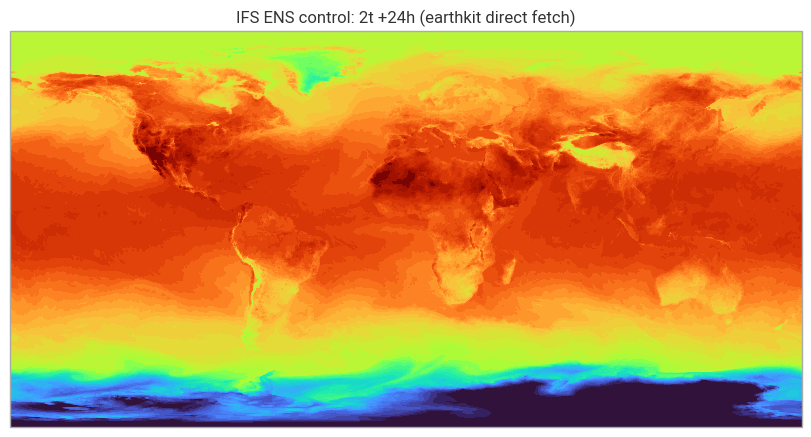

In [9]:
field = ds.sel(shortName="2t")[0]
m = ekp.Map()
m.quickplot(field)
m.title("IFS ENS control: 2t +24h (earthkit direct fetch)")
m.show()

### Troubleshooting
- **No steps found**: The run may not be published yet. Usually trying an earlier run fixes the issue.  
- **Plot fails**: Re-check the `shortName` in the Explore table; try `2t` or `msl` first.  

## Take-home messages

You have just:
- Understood the **ECMWF Open Data catalogue** structure and the **50r1 naming changes**
- Browsed the **live index** at `data.ecmwf.int` and picked a real run/step
- Downloaded a GRIB2 file using three methods (client, curl, HTTP Range)
- Inspected contents with `earthkit.data` and plotted a field by `shortName`

---

### Next steps

- **Notebook 03: Open Data: retrieval and plotting with earthkit**  
  Automate safe run/step selection; fetch IFS, AIFS, and ENS; compare models; Africa domain; vertical profile.

- **Notebook 04: Cloud endpoints (AWS S3, Azure, GCS)**  
  Fetch the same data without the `ecmwf-opendata` client using HTTP Range requests directly.

- **Notebook 05: Copernicus ERA5 via CDS**  
  Access climate reanalysis (1940-present) using `cdsapi` and `earthkit.data`.

### Support & feedback

- Questions and bug reports: [support.ecmwf.int](https://support.ecmwf.int)
- Open Data documentation: [confluence.ecmwf.int/display/DAC/ECMWF+open+data](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data)
- This notebook: [github.com/valtzen/demo](https://github.com/valtzen/demo)
